## Στόχος του προβλήματος

* Αντιμετωπίζουμε ένα **πρόβλημα δυαδικής ταξινόμησης (binary classification)**.
* Τα δεδομένα προέρχονται από το γνωστό **two-moons dataset**, το οποίο:

  * δεν είναι γραμμικά διαχωρίσιμο
  * απαιτεί μη-γραμμικά μοντέλα
* Στόχος:

  * να μάθουμε ένα **decision boundary**
  * να παρακολουθήσουμε **πώς αυτό εξελίσσεται κατά την εκπαίδευση**
* Δεν μας ενδιαφέρει μόνο το τελικό αποτέλεσμα,
  αλλά και **η δυναμική της μάθησης**.

---

## Δημιουργία δεδομένων

* Τα δεδομένα έχουν **2 χαρακτηριστικά (x₁, x₂)**.
* Κάθε δείγμα ανήκει σε μία από **δύο κλάσεις (0 ή 1)**.
* Προστίθεται **θόρυβος**, ώστε:

  * το πρόβλημα να μην είναι τετριμμένο
  * να προσομοιώνει πραγματικές συνθήκες
* Το σύνολο χωρίζεται σε:

  * **Training set (80%)**
  * **Test set (20%)**
* Το test set **δεν χρησιμοποιείται ποτέ στην εκπαίδευση**.

---

## Αρχιτεκτονική του μοντέλου

* Χρησιμοποιούμε ένα **πολυεπίπεδο νευρωνικό δίκτυο (MLP)**.

* Δομή:

  * Είσοδος: 2 χαρακτηριστικά
  * 3 κρυφά επίπεδα με **62 νευρώνες**
  * Ενεργοποίηση: **ReLU**
  * Έξοδος: 1 νευρώνας (logit)

* Το βάθος και το πλάτος δίνουν στο δίκτυο
  **ικανότητα να μάθει πολύπλοκα, μη-γραμμικά σύνορα**.

---

## Ερμηνεία του μοντέλου

* Το μοντέλο υπολογίζει:

  f(x) = W₄ σ(W₃ σ(W₂ σ(W₁ x)))

* Οι ReLU ενεργοποιήσεις δημιουργούν
  **κομμάτι-γραμμικές (piecewise linear) συναρτήσεις**.

* Στον 2D χώρο εισόδου:

  * το decision boundary αποτελείται από
  * πολλά τοπικά γραμμικά τμήματα

* Περισσότερα επίπεδα ⇒
  **πιο σύνθετα σύνορα απόφασης**.

---

## Εκπαίδευση

* Συνάρτηση κόστους:
  **Binary Cross-Entropy with Logits**

* Βελτιστοποιητής: **Adam**

* Εκπαίδευση με **full-batch gradient descent**

* Σε κάθε εποχή:

  * forward pass
  * υπολογισμός loss
  * backpropagation
  * ενημέρωση βαρών

* Η καμπύλη loss μας δείχνει αν:

  * το μοντέλο μαθαίνει
  * η εκπαίδευση είναι σταθερή

---

## Εξέλιξη του decision boundary

* Αποθηκεύουμε το decision boundary σε επιλεγμένες εποχές:

  * 1, 10, 50, 100, 200, 500

* Σε κάθε χρονική στιγμή:

  * υπολογίζουμε τις προβλέψεις σε ένα πυκνό πλέγμα
  * σχεδιάζουμε την καμπύλη πιθανότητας 0.5

---

## Ερμηνεία της εξέλιξης

* Στις αρχικές εποχές:

  * το boundary είναι σχεδόν τυχαίο
  * το μοντέλο βρίσκεται σε **underfitting**
* Καθώς αυξάνονται οι επαναλήψεις:

  * το boundary αρχίζει να λυγίζει
  * προσαρμόζεται στη γεωμετρία των δεδομένων
* Στις τελευταίες εποχές:

  * το boundary σταθεροποιείται
  * το μοντέλο έχει μάθει τη **μη-γραμμική δομή**

---

## Οπτικοποίηση & διδακτική αξία

* Η κοινή απεικόνιση:

  * training data
  * πολλαπλά decision boundaries
* μας επιτρέπει να δούμε:

  * **πώς “σκέφτεται” το δίκτυο**
  * πώς η μάθηση είναι **σταδιακή διαδικασία**
* Το τελικό boundary είναι αποτέλεσμα
  **πολλών μικρών βημάτων βελτιστοποίησης**.

---

## Αξιολόγηση & γενίκευση

* Η τελική αξιολόγηση γίνεται στο **test set**.
* Μετρική: **accuracy**
* Καλή ακρίβεια σημαίνει:

  * το μοντέλο έμαθε το γενικό μοτίβο
  * όχι απλή απομνημόνευση των δεδομένων
* Η σύγκριση train vs test δείχνει:
  **ικανότητα γενίκευσης**.
---

In [1]:
# -----------------------------
# Imports
# -----------------------------

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# -----------------------------
# Data collection
# -----------------------------

X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

# -----------------------------
# Train / Test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


In [3]:
# -----------------------------
# 3. Define the neural network
# -----------------------------

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 62),
            nn.ReLU(),
            nn.Linear(62, 62),
            nn.ReLU(),
            nn.Linear(62, 62),
            nn.ReLU(),
            nn.Linear(62, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Classifier()

In [4]:
# -----------------------------
# Loss function and optimizer
# -----------------------------

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch 100/500 - Loss: 0.1306
Epoch 200/500 - Loss: 0.0636
Epoch 300/500 - Loss: 0.0594
Epoch 400/500 - Loss: 0.0570
Epoch 500/500 - Loss: 0.0550


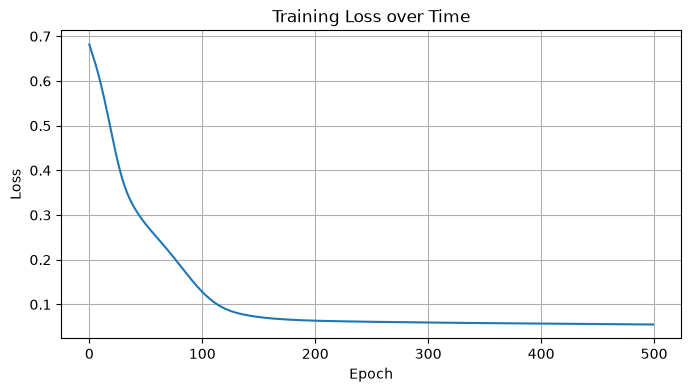

In [5]:
# -----------------------------
# Training loop
# -----------------------------

epochs = 500
loss_history = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")


# -----------------------------
# Plot loss
# -----------------------------

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.show()

## Training with Cumulative Learning Rate Schedule

Here, we'll implement a learning rate schedule to observe its effect on convergence. We'll start with a higher learning rate and reduce it over time. This approach can help the model explore the loss landscape more aggressively in the beginning and then fine-tune its parameters with smaller steps as training progresses, potentially leading to better convergence and avoiding oscillations.

In [6]:
# Initialize a new model and optimizer for this experiment
model_lr_schedule = Classifier()
criterion_lr_schedule = nn.BCEWithLogitsLoss()

# Start with a higher learning rate as requested
initial_lr = 0.1
optimizer_lr_schedule = optim.Adam(model_lr_schedule.parameters(), lr=initial_lr)

# Define a learning rate scheduler:
# Reduce the learning rate by a factor of 0.5 every 100 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer_lr_schedule, step_size=100, gamma=0.5)

epochs = 500 # Same number of epochs
loss_history_lr_schedule = []
lr_history = []

print(f"Training with cumulative learning rate (initial: {initial_lr})\n")

for epoch in range(epochs):
    model_lr_schedule.train()

    optimizer_lr_schedule.zero_grad()
    logits = model_lr_schedule(X_train_t)
    loss = criterion_lr_schedule(logits, y_train_t)
    loss.backward()
    optimizer_lr_schedule.step()

    # Step the scheduler to update the learning rate
    scheduler.step()

    loss_history_lr_schedule.append(loss.item())
    # Store the current learning rate
    lr_history.append(optimizer_lr_schedule.param_groups[0]['lr'])

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - LR: {optimizer_lr_schedule.param_groups[0]['lr']:.6f}")

Training with cumulative learning rate (initial: 0.1)

Epoch 100/500 - Loss: 0.0421 - LR: 0.050000
Epoch 200/500 - Loss: 0.0350 - LR: 0.025000
Epoch 300/500 - Loss: 0.0309 - LR: 0.012500
Epoch 400/500 - Loss: 0.0295 - LR: 0.006250
Epoch 500/500 - Loss: 0.0289 - LR: 0.003125


### Loss Curve with Learning Rate Schedule

This plot shows how the training loss evolves when a learning rate scheduler is applied. You can observe the effect of the learning rate reductions on the loss trajectory.

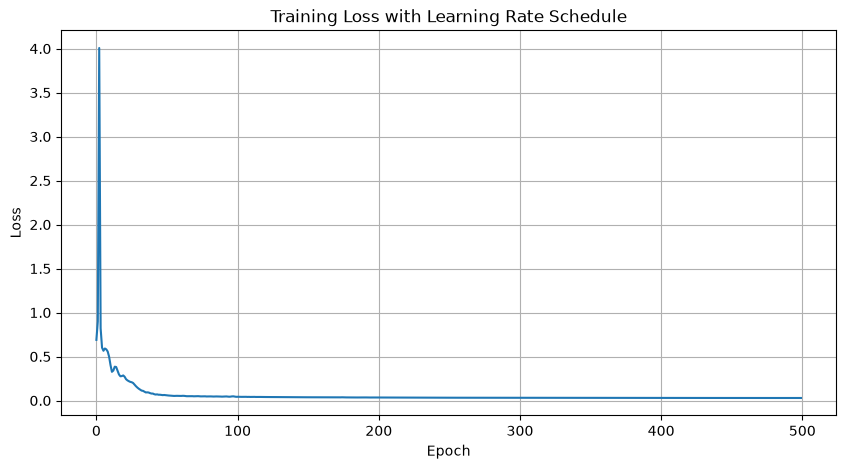

In [7]:
# Plot loss history for the model with LR schedule
plt.figure(figsize=(10, 5))
plt.plot(loss_history_lr_schedule)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss with Learning Rate Schedule")
plt.grid(True)
plt.show()

### Learning Rate Evolution

This plot visualizes how the learning rate changes over the course of training, as defined by the `StepLR` scheduler. You can clearly see the stepwise reductions.

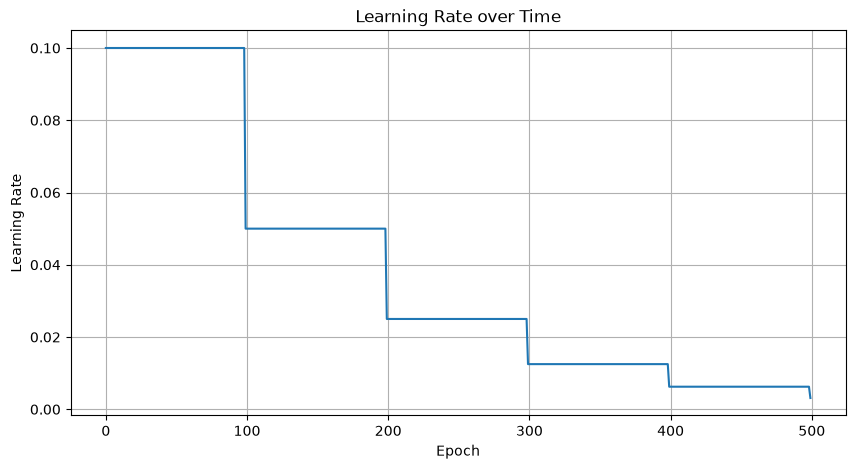

In [8]:
# Plot learning rate history
plt.figure(figsize=(10, 5))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate over Time")
plt.grid(True)
plt.show()

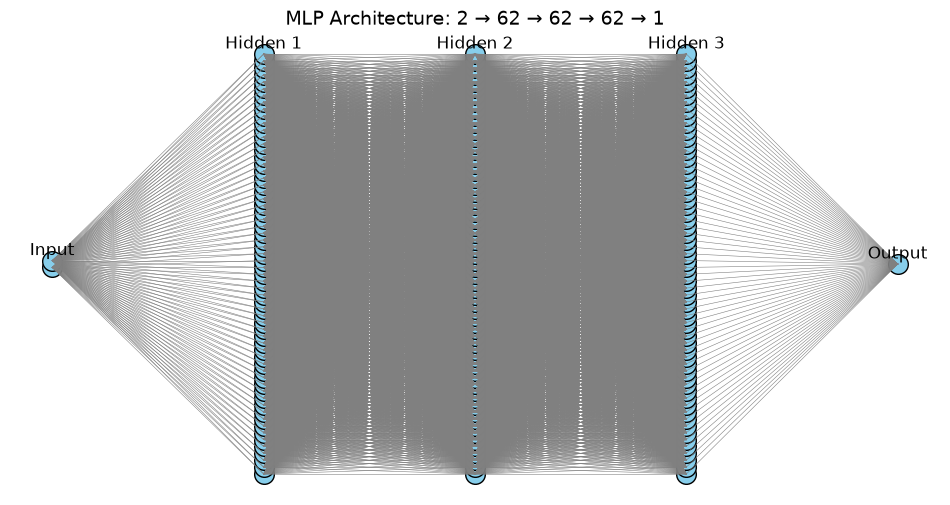

In [9]:
# -----------------------------
# Plot model architecture
# -----------------------------

layers = [2, 62, 62, 62, 1]

fig, ax = plt.subplots(figsize=(12, 6))

v_spacing = 1
h_spacing = 2

for i, n_neurons in enumerate(layers):
    y_positions = np.linspace(-(n_neurons-1)/2, (n_neurons-1)/2, n_neurons)
    x_positions = np.ones(n_neurons) * i * h_spacing

    ax.scatter(x_positions, y_positions, s=200, color='skyblue', edgecolors='k')

    if i == 0:
        label = "Input"
    elif i == len(layers) - 1:
        label = "Output"
    else:
        label = f"Hidden {i}"

    ax.text(i*h_spacing, max(y_positions)+0.8, label, ha='center', fontsize=12)

for i in range(len(layers)-1):
    y1 = np.linspace(-(layers[i]-1)/2, (layers[i]-1)/2, layers[i])
    y2 = np.linspace(-(layers[i+1]-1)/2, (layers[i+1]-1)/2, layers[i+1])

    for y_start in y1:
        for y_end in y2:
            ax.plot(
                [i*h_spacing, (i+1)*h_spacing],
                [y_start, y_end],
                'gray',
                linewidth=0.4
            )

ax.axis('off')
ax.set_title("MLP Architecture: 2 → 62 → 62 → 62 → 1", fontsize=14)
plt.show()

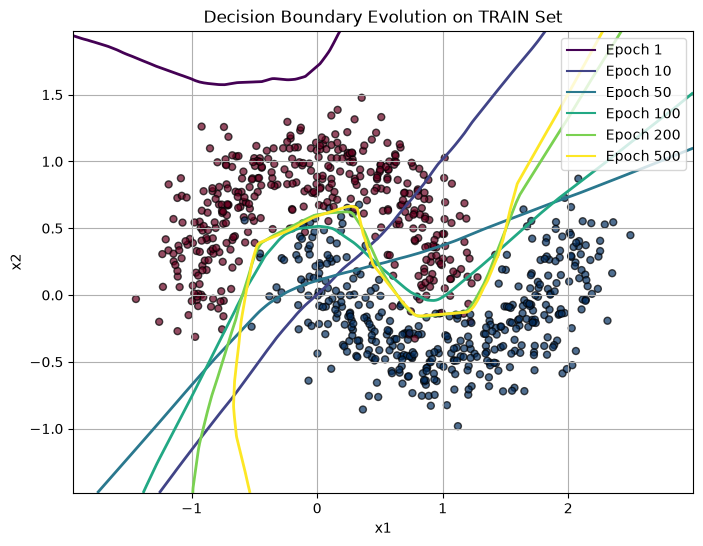

In [13]:
# -----------------------------
# Helper: decision boundary
# -----------------------------

def plot_decision_boundary(model, X, y, title):
    model.eval()

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).numpy()

    probs = probs.reshape(xx.shape)

    plt.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k", s=25)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


# ============================================================
# EXTRA: Decision boundary evolution on TRAIN set
# ============================================================

viz_model = Classifier()
viz_optimizer = optim.Adam(viz_model.parameters(), lr=0.001)
viz_criterion = nn.BCEWithLogitsLoss()

snapshot_epochs = [1, 10, 50, 100, 200, 500]
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshot_epochs)))

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

saved_boundaries = []
epoch_counter = 0

for epoch in range(epochs):
    viz_model.train()

    viz_optimizer.zero_grad()
    logits = viz_model(X_train_t)
    loss = viz_criterion(logits, y_train_t)
    loss.backward()
    viz_optimizer.step()

    epoch_counter += 1

    if epoch_counter in snapshot_epochs:
        viz_model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(viz_model(grid)).numpy()
        saved_boundaries.append(probs.reshape(xx.shape))


plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="RdBu",
    edgecolors="k",
    s=25,
    alpha=0.7
)

for i, boundary in enumerate(saved_boundaries):
    plt.contour(
        xx,
        yy,
        boundary,
        levels=[0.5],
        colors=[colors[i]],
        linewidths=2
    )

for i, ep in enumerate(snapshot_epochs):
    plt.plot([], [], color=colors[i], label=f"Epoch {ep}")

plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary Evolution on TRAIN Set")
plt.grid(True)
plt.show()

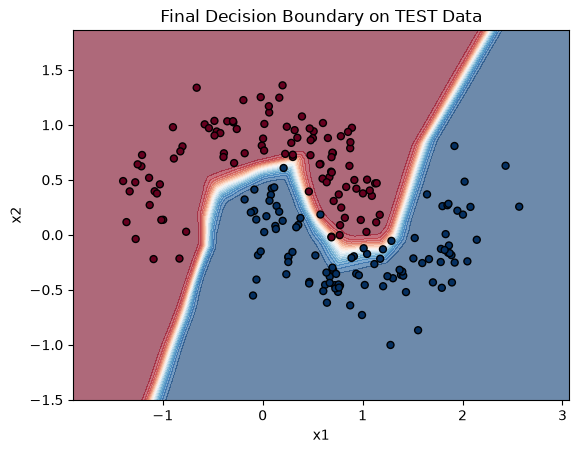

In [11]:
# -----------------------------
# Final plot: TEST data
# -----------------------------

plot_decision_boundary(
    model,
    X_test,
    y_test,
    title="Final Decision Boundary on TEST Data"
)

In [12]:
# -----------------------------
# Final evaluation
# -----------------------------

model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(model(X_test_t))
    test_pred = (test_probs > 0.5).int().numpy()

accuracy = accuracy_score(y_test, test_pred)
print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 0.99
